In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from maskvar.models.vqvae_single import VQVAE_Single
from maskvar.datasets import MaskLevelDatasetDummy
from maskvar.models.simple_ar import (
    SimpleVAR,
    simple_var_inference,
    simple_var_train_pass
)
from maskvar.maskseg_build_everything import (
    build_hqseg44k_dataset,
    build_simple_var,
    build_vqvae_single_5_stages_v1,
)

device = 'cuda'

In [2]:
def visualize(indices, device='cpu'):
    result = vqvae.idxBl_to_img(indices, same_shape=True)

    for i in range(len(indices)):
        print(f'index {i}: {indices[i].shape}')
    # result_conv = [edge(item) for item in result]
    result = [mask for mask in result]
    chw = torchvision.utils.make_grid(torch.cat(result, dim=0), nrow=3, padding=1, pad_value=1.0)

    chw = chw.permute(1, 2, 0).cpu().numpy()
    plt.imshow(chw[:, :, 0])
    plt.axis('off')

In [3]:
train_set, _ = build_hqseg44k_dataset('../data/sam-hq') # validate on train set
train_set_masklevel = MaskLevelDatasetDummy(
    dataset=train_set,
    sam_encoder=None,
    with_image_embed=False,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
    # count=5,
)
val_set_masklevel = MaskLevelDatasetDummy(
    dataset=train_set,
    sam_encoder=None,
    with_image_embed=False,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
    # count=5,
)

train_dataloader = DataLoader(train_set_masklevel, batch_size=1, shuffle=False, drop_last=True)

Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 1503985.36it/s]


In [4]:
data_iter = iter(train_dataloader)

In [5]:
image, image_embed_sam, single_mask_normalized, single_mask = next(iter(train_dataloader))
print("image.shape:", image.shape)
print("image_embed_sam.shape:", image_embed_sam.shape)
print("single_mask_normalized.shape:", single_mask_normalized.shape)
print("single_mask.shape:", single_mask.shape)

image.shape: torch.Size([1, 3, 1024, 1024])
image_embed_sam.shape: torch.Size([1])
single_mask_normalized.shape: torch.Size([1, 1, 256, 256])
single_mask.shape: torch.Size([1, 1, 256, 256])


In [6]:
simple_var: SimpleVAR = build_simple_var(simple_var_checkpoint_path='../out/simple_var_0_debug/checkpoints/.simple_var.80.pt', device=device)
vqvae: VQVAE_Single = build_vqvae_single_5_stages_v1('../out/out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth', require_grad=False)
vqvae = vqvae.to(device)

In [7]:
id_seq = simple_var_inference(simple_var, vqvae, batch_size=1)

simple_var.patch_num: [1, 8, 16, 24, 32]
scale, pn: 0, 1
current_token shape: torch.Size([1, 1, 256])


logits_flat shape: torch.Size([1, 4096])
next_tokens shape: torch.Size([1, 1])
next_tokens shape: torch.Size([1, 1])
scale, pn: 1, 8
current_token shape: torch.Size([1, 64, 256])
logits_flat shape: torch.Size([64, 4096])
next_tokens shape: torch.Size([64, 1])
next_tokens shape: torch.Size([1, 64])
scale, pn: 2, 16
current_token shape: torch.Size([1, 256, 256])
logits_flat shape: torch.Size([256, 4096])
next_tokens shape: torch.Size([256, 1])
next_tokens shape: torch.Size([1, 256])
scale, pn: 3, 24
current_token shape: torch.Size([1, 576, 256])
logits_flat shape: torch.Size([576, 4096])
next_tokens shape: torch.Size([576, 1])
next_tokens shape: torch.Size([1, 576])
scale, pn: 4, 32
current_token shape: torch.Size([1, 1024, 256])
logits_flat shape: torch.Size([1024, 4096])
next_tokens shape: torch.Size([1024, 1])
next_tokens shape: torch.Size([1, 1024])


In [8]:
for t in id_seq:
    print(t.shape)

torch.Size([1, 1])
torch.Size([1, 64])
torch.Size([1, 256])
torch.Size([1, 576])
torch.Size([1, 1024])


In [9]:
idx = vqvae.img_to_idxBl(single_mask_normalized.to(device))
for t in idx:
    print(t.shape)

torch.Size([1, 1])
torch.Size([1, 64])
torch.Size([1, 256])
torch.Size([1, 576])
torch.Size([1, 1024])


index 0: torch.Size([1, 1])
index 1: torch.Size([1, 64])
index 2: torch.Size([1, 256])
index 3: torch.Size([1, 576])
index 4: torch.Size([1, 1024])


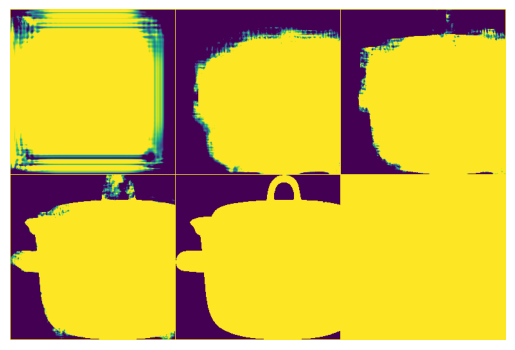

In [10]:
visualize(idx, device)

index 0: torch.Size([1, 1])
index 1: torch.Size([1, 64])
index 2: torch.Size([1, 256])
index 3: torch.Size([1, 576])
index 4: torch.Size([1, 1024])


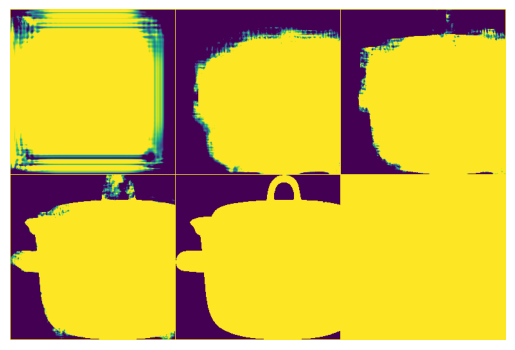

In [11]:
visualize(id_seq, device)

In [12]:
a = torch.cat(id_seq, dim=1)
b = torch.cat(idx, dim=1)
print((a == b).sum())

tensor(1921, device='cuda:0')


In [13]:
a[:, :30]

tensor([[2367,  651, 2969, 2969, 2969, 2852,  142, 3152, 2969, 2969, 2969, 1486,
         2907, 3324, 3891, 3506,  918, 2666, 1463, 2367, 2367, 2907, 2907, 2907,
         1548, 2969, 2367, 2367, 2367, 2367]], device='cuda:0')

In [14]:
b[:, :30]

tensor([[2367,  651, 2969, 2969, 2969, 2852,  142, 3152, 2969, 2969, 2969, 1486,
         2907, 3324, 3891, 3506,  918, 2666, 1463, 2367, 2367, 2907, 2907, 2907,
         1548, 2969, 2367, 2367, 2367, 2367]], device='cuda:0')

In [15]:
logits = simple_var_train_pass(idx, simple_var, vqvae)
# sample the max token
id_seq_teach = logits.argmax(dim=-1)
print(f"id_seq_teach shape: {id_seq_teach.shape}")

id_seq_teach shape: torch.Size([1, 1921])


In [16]:
id_seq_teach_Bl = []
start_pos = 0
for pn in simple_var.patch_num:
    end_pos = start_pos + pn * pn
    id_seq_teach_Bl.append(id_seq_teach[:, start_pos:end_pos])
    start_pos = end_pos

index 0: torch.Size([1, 1])
index 1: torch.Size([1, 64])
index 2: torch.Size([1, 256])
index 3: torch.Size([1, 576])
index 4: torch.Size([1, 1024])


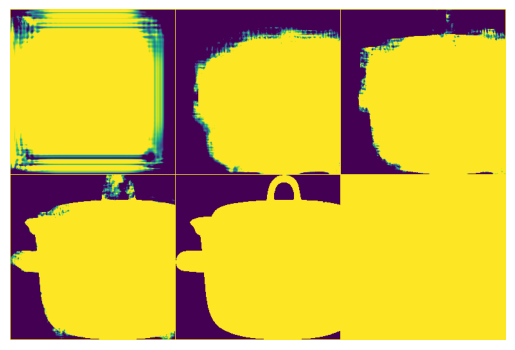

In [17]:
visualize(id_seq_teach_Bl, device)